### Function and Class Definitions

In [1]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display, clear_output
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (8,5),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)

In [2]:
import time
import torch
import numpy as np
import torch.nn as nn
from neurodiffeq import diff      
from neurodiffeq.ode import solve 
from neurodiffeq.conditions import IVP 
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import Solver1D
from neurodiffeq.generators import Generator1D
from neurodiffeq.monitors import BaseMonitor

C:\Users\laksh\anaconda3\envs\torch\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
class SineActivation(nn.Module):
    def forward(self, input):
        return torch.sin(input)

In [4]:
class CustomNN(nn.Module):
    def __init__(self, n_input_units=1, hidden_units=[16,16], actv=SineActivation, n_output_units=1, t_min=0, t_max=1, mu_learnable=False, sigma_learnable=True):
        super(CustomNN, self).__init__()

        # Layers list to hold all layers
        self.layers = nn.ModuleList()

        # First hidden layer with special behavior
        self.layers.append(nn.Linear(n_input_units, hidden_units[0]))

        # Learnable parameters mu and sigma for the firs layer
        if mu_learnable:
            self.mu = nn.Parameter(torch.linspace(t_min,t_max, hidden_units[0]))
        else:
            self.mu =  torch.linspace(t_min,t_max, hidden_units[0])
        if sigma_learnable:
            self.sigma = nn.Parameter(torch.ones(hidden_units[0])*((t_max-t_min)/hidden_units[0]))
        else:
            self.sigma = torch.ones(hidden_units[0])*(0.1)

        # Remaining hidden layers
        for i in range(len(hidden_units) - 1):
            self.layers.append(actv())
            self.layers.append(nn.Linear(hidden_units[i], hidden_units[i+1]))

        # Output layer
        self.layers.append(actv())
        self.fc_out = nn.Linear(hidden_units[-1], n_output_units)

    def forward(self, x):

        #inputx = x[:,0].reshape(-1,1)
        #print(inputx.shape)
        for layer in self.layers:
            x = layer(x)
            if 'Linear' in str(nets[0].layers[0]):
                x = x * torch.exp(- (x - self.mu) ** 2 / (2 * self.sigma ** 2))

        # Output layer transformation
        x = self.fc_out(x)
        return x

In [5]:
class Monitor(BaseMonitor):
    """A monitor for checking the status of the neural network during training.

    :param t_min:
        The lower bound of time domain that we want to monitor.
    :type t_min: float
    :param t_max:
        The upper bound of time domain that we want to monitor.
    :type t_max: float
    :param check_every:
        The frequency of checking the neural network represented by the number of epochs between two checks.
        Defaults to 100.
    :type check_every: int, optional
    """

    def __init__(self, solver, t_min, t_max, check_every=100):
        """Initializer method
        """
        super(Monitor, self).__init__(check_every=check_every)
        self.solver = solver
        self.fig = plt.figure(figsize=(12, 8))
        self.ax0 = self.fig.add_subplot(311)
        self.ax1 = self.fig.add_subplot(323)
        self.ax2 = self.fig.add_subplot(324)
        self.ax3 = self.fig.add_subplot(325)
        self.ax4 = self.fig.add_subplot(326)
        # input for plotting
        self.ts_plt = np.linspace(t_min, t_max, 100)
        # input for neural network
        self.ts_ann = torch.linspace(t_min, t_max, 100, requires_grad=True).reshape((-1, 1))

        if torch.cuda.is_available():
            mus = solver.nets[0].mu.cpu().detach().numpy()
            sigma = solver.nets[0].sigma.cpu().detach().numpy()
        else:
            mus = solver.nets[0].mu
            sigma = solver.nets[0].sigma
        mu_plus_sigma = mus + sigma
        mu_minus_sigma = mus - sigma    
        self.dim = 16

        self.t = torch.linspace(0,1,self.dim).reshape(-1,1)
        self.t_plt = self.t.cpu().detach().numpy().reshape(-1)
        
        # Step 4: Create the 16 x n matrix
        self.upper_bound = np.tile(mu_plus_sigma[:, np.newaxis], (1, self.dim))
        self.lower_bound = np.tile(mu_minus_sigma[:, np.newaxis], (1, self.dim))

        del mu_plus_sigma, mu_minus_sigma, mus, sigma
        ## To create a gaussian
        # # Define parameters
        # x0, y0 = 0, solver.nets[0].layers[0].out_features-1  # Starting point
        # x1, y1 = solver.nets[0].layers[0].out_features-1, 0  # Ending point
        # num_gaussians = y0  # Number of Gaussians
        # sigma = 1  # Sigma for Gaussians
        
        # # Generate x and y values for the line
        # x_vals = np.linspace(x0, x1, num_gaussians + 2)[1:-1]  # Exclude endpoints
        # y_vals = np.linspace(y0, y1, num_gaussians + 2)[1:-1]  # Exclude endpoints
        
        # # Create a grid for the heatmap
        # x = np.linspace(0, solver.nets[0].layers[0].out_features, 1000)
        # y = np.linspace(0, solver.nets[0].layers[0].out_features, 1000)
        # X, Y = np.meshgrid(x, y)
        
        # # Initialize the heatmap as zeros
        # heatmap = np.zeros_like(X)
        
        # # Generate Gaussian distributions and add them to the heatmap
        # for x_val, y_val in zip(x_vals, y_vals):
        #     gaussian = np.exp(-((X - x_val) ** 2 + (Y - y_val) ** 2) / (2 * sigma ** 2))
        #     heatmap += gaussian

        # self.heatmap = heatmap
        # self.dim = y0
        # del heatmap, X, Y, gaussian, x, y, x_vals, y_vals

    def check(self, nets, conditions, history):
        r"""Draw 2 plots: One shows the shape of the current solution.
        The other shows the history training loss and validation loss.

        :param nets:
            The neural networks that approximates the ODE (system).
        :type nets: list[`torch.nn.Module`]
        :param conditions:
            The initial/boundary conditions of the ODE (system).
        :type conditions: list[`neurodiffeq.ode.BaseCondition`]
        :param history:
            The history of training loss and validation loss.
            The 'train_loss' entry is a list of training loss and 'valid_loss' entry is a list of validation loss.
        :type history: dict['train': list[float], 'valid': list[float]]

        .. note::
            `check` is meant to be called by the function `solve` and `solve_system`.
        """

        us = [
            cond.enforce(net, self.ts_ann).detach().cpu().numpy()
            for cond, net in zip(conditions, nets)
        ]

        residuals = self.solver.get_residuals(self.ts_ann, to_numpy=True)

        self.ax0.clear()
        self.ax0.axline((0,0), (len(history["train_loss"]),0), linewidth = 8, color = '#0afa9e')
        self.ax0.set_yticklabels([]) 
        self.ax0.spines['top'].set_visible(False)
        self.ax0.spines['right'].set_visible(False)
        self.ax0.spines['bottom'].set_visible(False)
        self.ax0.spines['left'].set_visible(False)

        
        # Plot the loss subplot
        self.ax1.clear()
        for i, u in enumerate(us):
            self.ax1.plot(self.ts_plt, u, label=f'variable {i}')
        self.ax1.plot(self.solver.best_nets[0].mu.cpu().detach().numpy(), self.solver.best_nets[0].sigma.cpu().detach().numpy(), label='MUs and Sigmas', 
                      c = colors[-1], alpha = 0.7, linestyle= '--')
        self.ax1.set_title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
        self.ax1.set_ylabel('u')
        self.ax1.set_xlabel('t')
        self.ax1.grid(True)
        
        self.ax2.clear()
        self.ax2.plot(np.log10(history['train_loss']), label='training loss', c=colors[-2])
        self.ax2.set_title('Loss Plot')
        self.ax2.set_ylabel('Loss')
        self.ax2.set_xlabel('Epochs')
        self.ax2.grid(True)
        #self.ax2.legend()
        
        self.ax3.clear()
        self.ax3.plot(self.ts_plt, residuals, c=colors[-3])
        self.ax3.set_title(f'Residuals')
        self.ax3.set_xlabel('t')
        self.ax3.set_ylabel('Residuals')
        self.ax3.grid(True)

        self.ax4.clear()
        output = torch.abs(solver.best_nets[0].layers[0](self.t)).T.cpu().detach().numpy()
        o_max = output.max()
        mask = (self.lower_bound<=output) & (output>=self.upper_bound)
        cmap = ListedColormap(['black', 'green'])
        bounds = [0, 1e-15, o_max]
        norm = BoundaryNorm(bounds, cmap.N)
        activated_regions = np.where(mask, output, 0)
        plt.imshow(activated_regions, cmap=cmap, norm=norm)
        self.ax4.set_xticks([])
        self.ax4.set_yticks([])
        self.ax4.grid(True, color='#0afa9e')
        plt.tight_layout()
        display(self.fig)
        clear_output(wait=True)

### DE definition

In [6]:
def harmonic_oscillator(u, t):
    return [diff(u, t, order=2) + 16*torch.pi**2*torch.sin(u)]
init_val_ho = [IVP(t_0=0.0, u_0=0.0, u_0_prime=1.0)]
t_min = 0
t_max = 1
train_batch_size = 256
valid_batch_size = 64
mu = False
sigma = False
nets = [CustomNN(n_input_units=1, n_output_units=1, hidden_units=[16, 16, 16, 16, 16], t_min=t_min, t_max=t_max, mu_learnable=mu, sigma_learnable=sigma)]
train_g = Generator1D(train_batch_size, t_min, t_max , method='equally-spaced-noisy')
valid_g = Generator1D(valid_batch_size, t_min, t_max , method='uniform')
optimizer = torch.optim.Adam([p for net in nets for p in net.parameters()],lr = 1e-3)
solver = Solver1D(ode_system=harmonic_oscillator, 
                    conditions=init_val_ho, 
                    t_min=t_min, 
                    t_max=t_max,
                    n_batches_valid=0,
                    train_generator=train_g,
                    valid_generator=valid_g,
                    nets = nets,
                    optimizer=optimizer)


KeyboardInterrupt



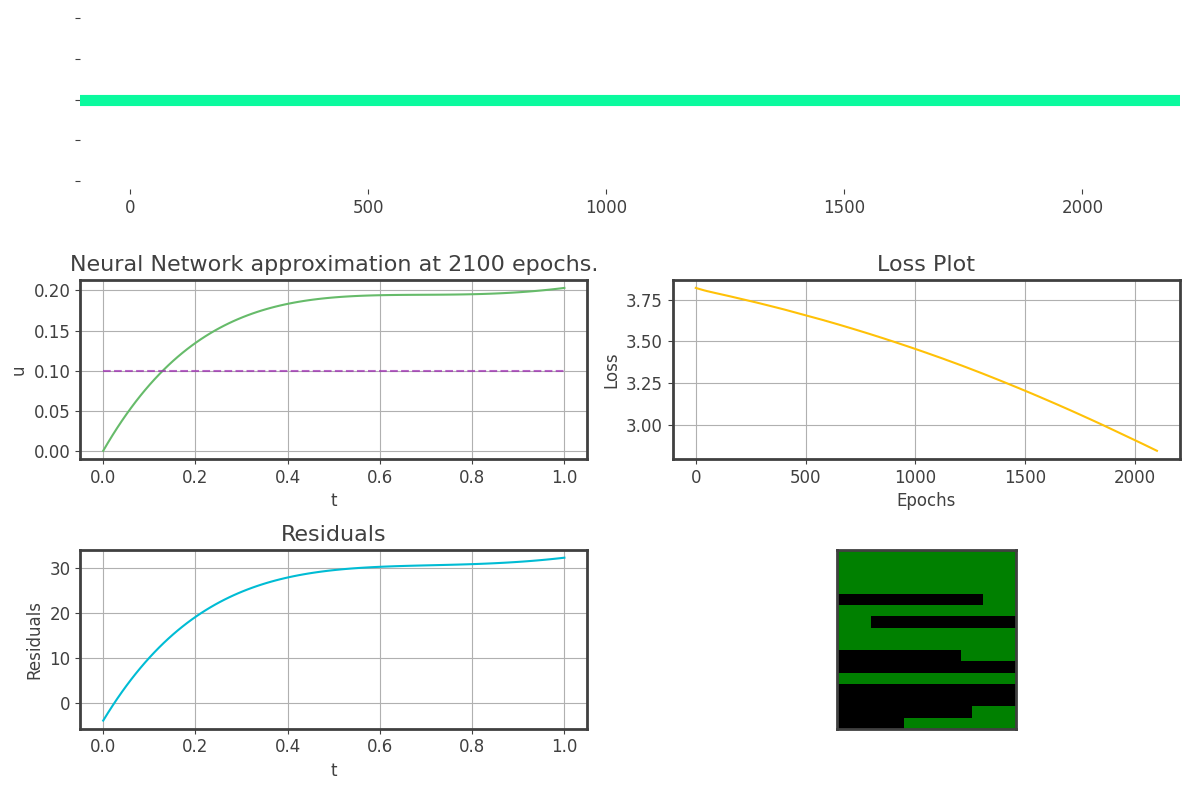

In [7]:
start = time.time()
epochs = 5000
monitor = Monitor(solver, t_min, t_max, check_every=100)
solver.fit(max_epochs=epochs, callbacks=[monitor.to_callback(fig_dir = 'temp')])

In [ ]:
time.time()-start

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params = count_parameters(nets[0])
print(f'Total number of parameters: {num_params}')

### Trying codes

In [ ]:
# t = torch.linspace(0,1,10).reshape(-1,1)
# output = torch.abs(solver.best_nets[0].layers[0](t)).T.cpu().detach().numpy()
# print(output.shape)
# o_max = output.max()
# print(o_max)
# r_max = output.max(axis=1)

In [ ]:
# import numpy as np

# # Step 1: Define mus and sigma
# mus = np.linspace(0, 1, 16)
# sigma = 0.1

# # Step 2: Calculate mu + sigma for each mu
# mu_plus_sigma = mus + sigma
# mu_minus_sigma = mus - sigma

# # Step 3: Define n (number of repetitions)
# n = 10  # for example, you can choose any integer value for n

# # Step 4: Create the 16 x n matrix
# upper_bound = np.tile(mu_plus_sigma[:, np.newaxis], (1, n))
# lower_bound = np.tile(mu_minus_sigma[:, np.newaxis], (1, n))

# mask = (lower_bound<=output) & (output>=upper_bound)
# activated_regions = np.where(mask, output, 0)

In [ ]:
# from matplotlib.colors import ListedColormap, BoundaryNorm
# fig = plt.figure(figsize=(5, 5))
# cmap = ListedColormap(['black', 'green'])
# bounds = [0, 1e-15, o_max]
# norm = BoundaryNorm(bounds, cmap.N)
# # cmap = ListedColormap(['black', 'red', 'lavender', 'green'])
# # bounds = [0, 0.25*o_max, 0.5*o_max, 0.75*o_max, o_max]
# # norm = BoundaryNorm(bounds, cmap.N)
# plt.imshow(activated_regions, cmap=cmap, norm=norm)
# # Turn off xticks and yticks
# plt.xticks([])
# plt.yticks([])
# plt.show()

In [ ]:
# hm  = sns.heatmap(output, cmap="inferno", xticklabels=False, yticklabels=False)
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define parameters
# x0, y0 = 0, 9  # Starting point
# x1, y1 = 9, 0  # Ending point
# num_gaussians = 10  # Number of Gaussians
# sigma = 1  # Sigma for Gaussians

# # Generate x and y values for the line
# x_vals = np.linspace(x0, x1, num_gaussians + 2)[1:-1]  # Exclude endpoints
# y_vals = np.linspace(y0, y1, num_gaussians + 2)[1:-1]  # Exclude endpoints

# # Create a grid for the heatmap
# x = np.linspace(0, 9, 1000)
# y = np.linspace(0, 9, 1000)
# X, Y = np.meshgrid(x, y)

# # Initialize the heatmap as zeros
# heatmap = np.zeros_like(X)

# # Generate Gaussian distributions and add them to the heatmap
# for x_val, y_val in zip(x_vals, y_vals):
#     gaussian = np.exp(-((X - x_val) ** 2 + (Y - y_val) ** 2) / (2 * sigma ** 2))
#     heatmap += gaussian

# # Plot the heatmap with a custom colorbar
# plt.figure(figsize=(5, 5))
# plt.imshow(heatmap, extent=[0, 9, 0, 9], origin='lower', cmap='Reds', alpha = 0.8)  # Change the colormap here
# plt.xlim(0,9)
# plt.ylim(0,9)



# cmap = ListedColormap(['black','lavender', 'green'])
# bounds = [0, o_max/3, 2*o_max/3, o_max]
# norm = BoundaryNorm(bounds, cmap.N)
# # cmap = ListedColormap(['black', 'red', 'lavender', 'green'])
# # bounds = [0, 0.25*o_max, 0.5*o_max, 0.75*o_max, o_max]
# # norm = BoundaryNorm(bounds, cmap.N)
# plt.imshow(output, cmap=cmap, norm=norm, alpha = 0.7)
# plt.colorbar()
# plt.xticks([])
# plt.yticks([])
# plt.grid()
# plt.show()
